# Sports Analytics Club: Intro EDA (Answer Key)

Welcome! This version is the fully completed notebook for mentors and workshop leads.

What we are doing today:
- quick data check-in
- filter to one season
- build two clean visuals
- optional challenge: build first-round matchup visuals from the 68-team field

No machine learning models here, just practical EDA with pandas + seaborn.

## Local VS Code vs Google Colab Data Access

Use this notebook in either environment:
- **VS Code (repo clone):** data should already be in `data/processed/club_share`.
- **Google Colab:** upload the needed CSV files to `/content` (or a subfolder), then set `COLAB_DATA_DIR`.

Needed files (change `m_` to `w_` for womens):
- `m_team_aggregates_2005_2026.csv`
- `m_modeling_matchups_2026_all_possible.csv`

Tip: if paths fail in Colab, run `!ls /content` in a cell to see exactly where your files landed.

In [26]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

In [27]:
# Change this to 'w' for womens data
DATA_PREFIX = "m"
SEASON = 2026

# If using Colab uploads, set this to where your CSV files live (example: Path('/content'))
COLAB_DATA_DIR = Path("/content")

IN_COLAB = False
try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    share_path = COLAB_DATA_DIR
else:
    project_root = Path.cwd().parent if Path.cwd().name.lower() == "notebooks" else Path.cwd()
    share_path = project_root / "data" / "processed" / "club_share"

team_agg_path = share_path / f"{DATA_PREFIX}_team_aggregates_2005_2026.csv"
matchups_all_path = share_path / f"{DATA_PREFIX}_modeling_matchups_2026_all_possible.csv"

required_paths = [team_agg_path, matchups_all_path]
missing_paths = [str(p) for p in required_paths if not p.exists()]
if missing_paths:
    raise FileNotFoundError("Missing files: " + ", ".join(missing_paths))

team_agg = pd.read_csv(team_agg_path)
matchups_all = pd.read_csv(matchups_all_path)

league_label = "Mens" if DATA_PREFIX.lower() == "m" else "Womens"
print(f"Loaded {league_label} data")
print(f"team_agg rows: {len(team_agg):,}")
print(f"modeling matchups rows: {len(matchups_all):,}")

Loaded Mens data
team_agg rows: 7,798
modeling matchups rows: 2,278


## 1) Data Inspection
Before plotting anything, get your bearings.

If your columns are not what you expected, catch it now and save yourself 20 minutes later.

In [28]:
display(team_agg.head())
print(f"Shape: {team_agg.shape}")
team_agg.info()

,Season,TeamID,TeamName,Seed,Adj_Massey,Adj_Seed,Colley_Momentum,Final_Colley,Final_Massey,Massey_Momentum,...,net_stl_pct,net_tov,playmaking_defense_composite,pyth_win_pct,sos_adj_net_rating,three_factors_composite,weighted_massey_momentum,TeamColor,TeamAlternateColor,TeamLogo
0,2005,1102,Air Force,NaN,NaN,10.0,0.005257,0.653719,9.771301,0.541365,...,0.077645,0.122067,1.490112,0.812950,0.661508,0.988058,0.191098,003594,ffffff,https://a.espncdn.com/i/teamlogos/ncaa/500/200...
1,2005,1103,Akron,NaN,NaN,11.0,0.033315,0.663638,8.113312,-0.436603,...,-0.003786,0.021854,0.567715,0.684013,0.119696,0.353393,-0.170160,00285e,84754e,https://a.espncdn.com/i/teamlogos/ncaa/500/200...
2,2005,1104,Alabama,X05,1.822595,6.0,-0.013250,0.882528,16.873810,0.932868,...,-0.016825,-0.018866,0.454006,0.831679,8.177312,0.671591,0.192873,9e1632,ffffff,https://a.espncdn.com/i/teamlogos/ncaa/500/333...
3,2005,1105,Alabama A&M,Z16a,-8.689297,16.0,-0.020848,0.260635,-11.272931,-0.758427,...,0.045611,0.054755,0.393136,0.442831,-21.182727,0.150278,-0.219606,790000,ffffff,https://a.espncdn.com/i/teamlogos/ncaa/500/201...
4,2005,1106,Alabama St,NaN,NaN,16.0,-0.027619,0.359524,-13.616421,-0.599609,...,0.001580,0.011847,-0.467832,0.283538,-26.221520,-0.283672,-0.137996,e9a900,0a0a0a,https://a.espncdn.com/i/teamlogos/ncaa/500/201...


Shape: (7798, 63)
<class 'pandas.DataFrame'>
RangeIndex: 7798 entries, 0 to 7797
Data columns (total 63 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Season                        7798 non-null   int64  
 1   TeamID                        7798 non-null   int64  
 2   TeamName                      7798 non-null   str    
 3   Seed                          1406 non-null   str    
 4   Adj_Massey                    1406 non-null   float64
 5   Adj_Seed                      7798 non-null   float64
 6   Colley_Momentum               7798 non-null   float64
 7   Final_Colley                  7798 non-null   float64
 8   Final_Massey                  7798 non-null   float64
 9   Massey_Momentum               7798 non-null   float64
 10  Relative_Colley_Momentum      7798 non-null   float64
 11  Relative_Massey_Momentum      7798 non-null   float64
 12  SeedNum                       1406 non-null   float64
 

## 2) Filter to Season + Missing Values
Let us focus on one year so the chart tells a clean story.

Missing values matter because they can silently remove teams from visualizations.

In [29]:
season_df = team_agg[team_agg["Season"] == SEASON].copy()
print(f"Rows in season {SEASON}: {len(season_df):,}")

key_cols = ["TeamName", "Final_Massey", "avg_off_rating", "avg_def_rating", "SeedNum"]
missing_summary = season_df[key_cols].isna().sum().sort_values(ascending=False)
display(missing_summary.to_frame(name="missing_count"))

Rows in season 2026: 366


,missing_count
SeedNum,302
TeamName,0
Final_Massey,0
avg_off_rating,0
avg_def_rating,0


## 3) Bar Chart: Top 10 Final Massey Teams in 2026
No averaging across years here.

This is simply: who had the strongest Final Massey in this one season?

C:\Users\ekerv\AppData\Local\Temp\ipykernel_21872\3942416717.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=bar_df, x="Final_Massey", y="TeamName", palette="Blues_r")


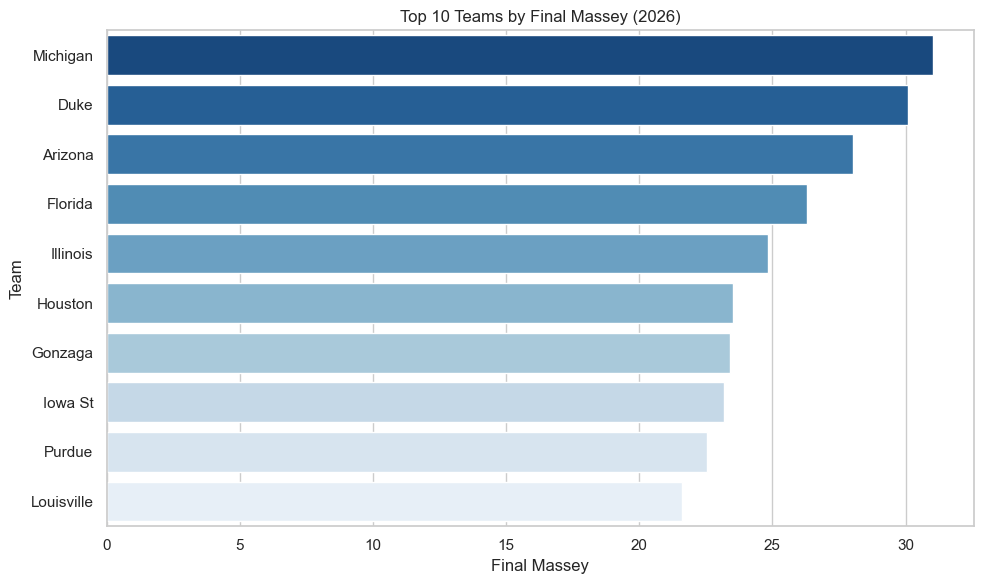

In [30]:
bar_df = (
    season_df.dropna(subset=["Final_Massey", "TeamName"])
    .sort_values("Final_Massey", ascending=False)
    .head(10)
    .copy()
)

plt.figure(figsize=(10, 6))
sns.barplot(data=bar_df, x="Final_Massey", y="TeamName", palette="Blues_r")
plt.title(f"Top 10 Teams by Final Massey ({SEASON})")
plt.xlabel("Final Massey")
plt.ylabel("Team")
plt.tight_layout()
plt.show()

## 4) Scatter Plot Progression: Offense vs Defense
Let us build this chart in stages so each upgrade is obvious.

Steps:
1. Plot all teams as-is.
2. Flip defense so better defenses appear higher on the chart.
3. Filter to tournament teams only.
4. Label the top 10 teams by combined score (`avg_off_rating - avg_def_rating`).

There is also an optional helper snippet left commented out at first, so the progression stays easy to follow.

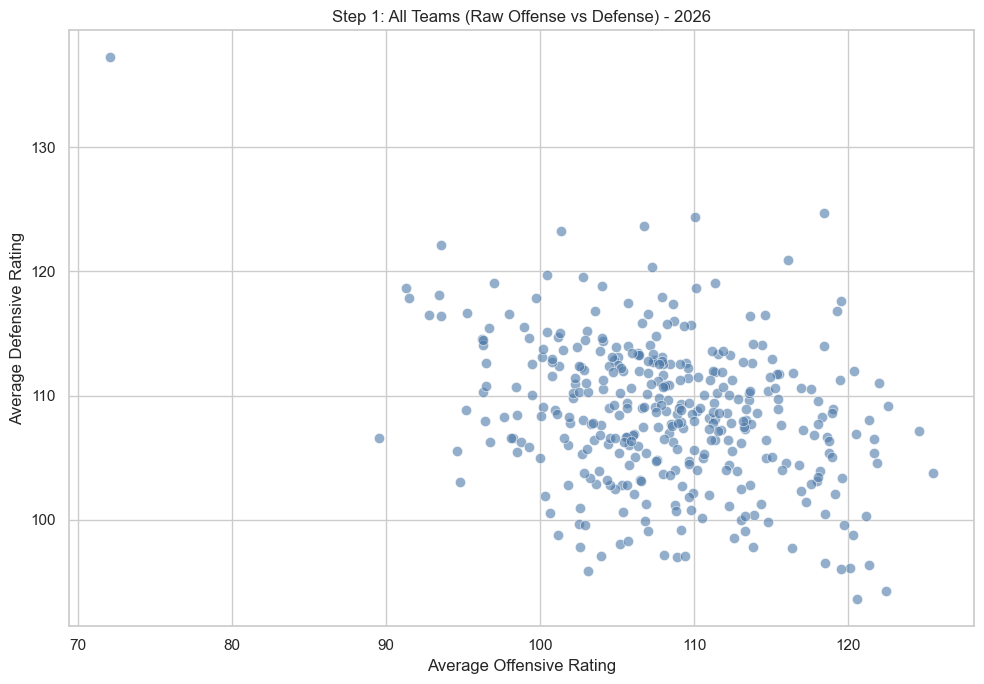

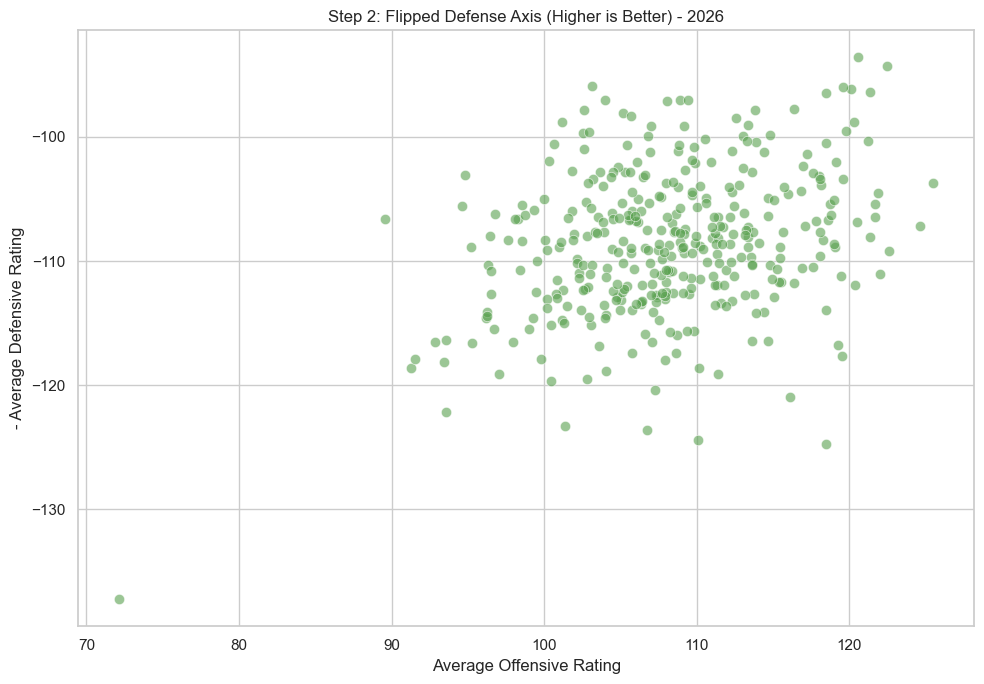

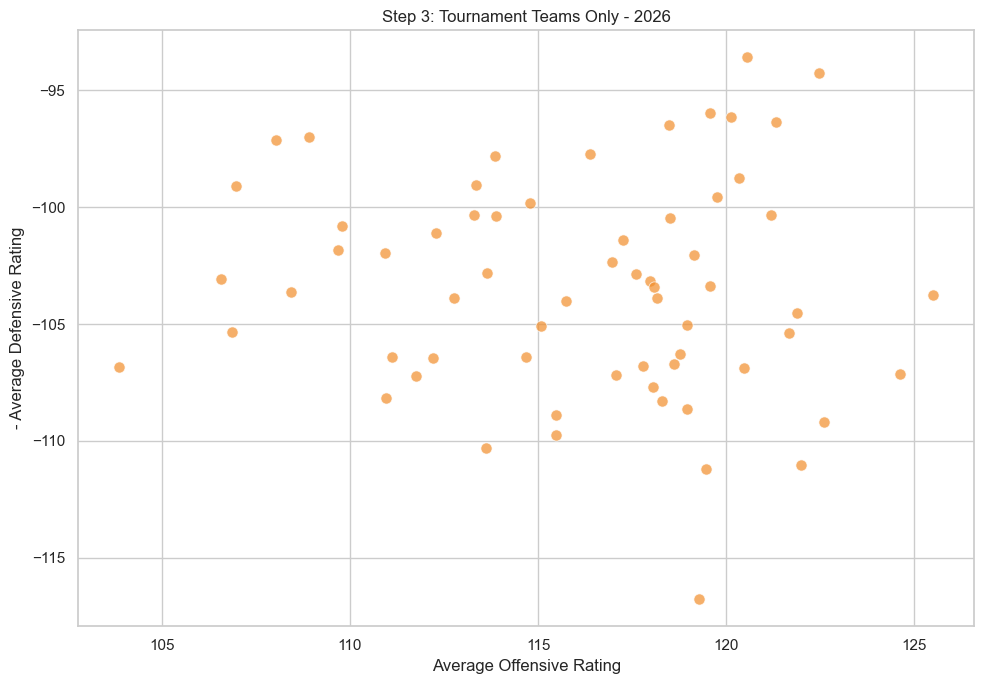

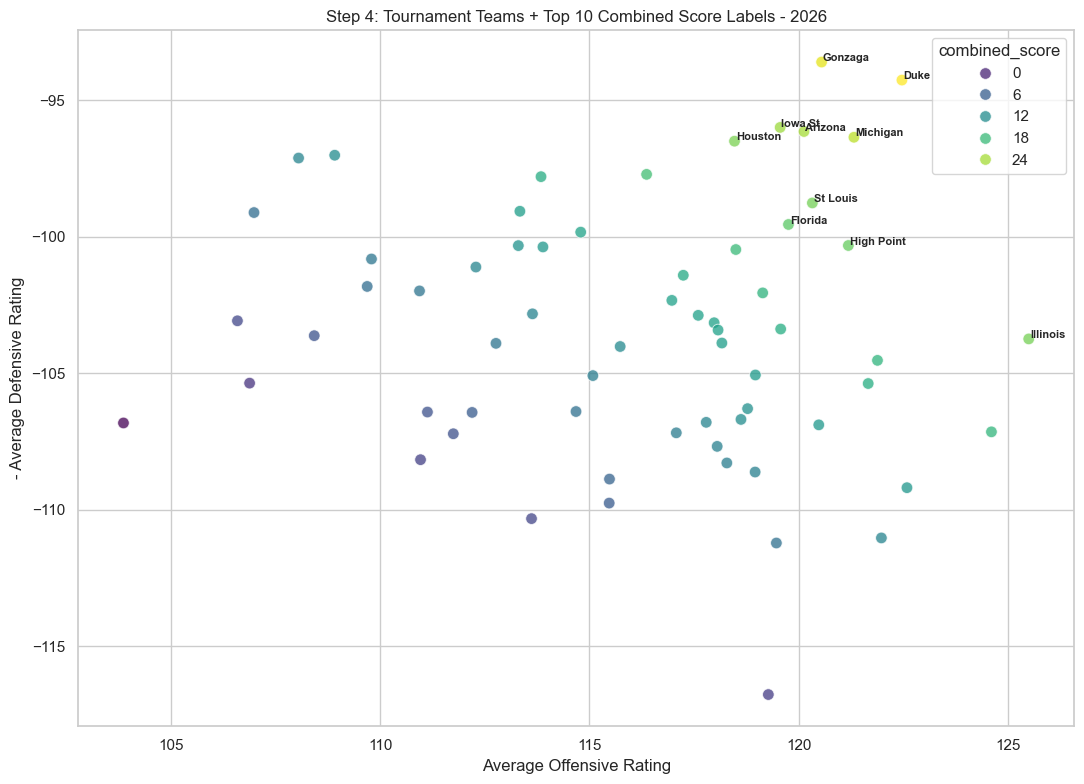

In [ ]:
scatter_base = season_df.dropna(
    subset=["avg_off_rating", "avg_def_rating", "Final_Massey", "TeamName"]
).copy()

if scatter_base.empty:
    raise RuntimeError("No rows available for offense/defense scatter after dropping missing values.")

# Optional helper to label teams. Keep this commented at first so the step-by-step flow stays clear.
# def label_teams(ax, label_df, x_col, y_col, text_col):
#     for _, row in label_df.iterrows():
#         ax.text(
#             row[x_col] + 0.03,
#             row[y_col] + 0.03,
#             str(row[text_col]),
#             fontsize=8,
#             fontweight="bold",
#             alpha=0.9,
#         )

# Step 1: all teams, raw offense vs defense.
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=scatter_base,
    x="avg_off_rating",
    y="avg_def_rating",
    alpha=0.6,
    s=55,
    color="#4C78A8",
)
plt.title(f"Step 1: All Teams (Raw Offense vs Defense) - {SEASON}")
plt.xlabel("Average Offensive Rating")
plt.ylabel("Average Defensive Rating")
plt.tight_layout()
plt.show()

In [ ]:
# Step 2: flip defense so lower def rating is better (higher on chart).
scatter_base["defense_better_high"] = -scatter_base["avg_def_rating"]

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=scatter_base,
    x="avg_off_rating",
    y="defense_better_high",
    alpha=0.6,
    s=55,
    color="#59A14F",
)
plt.title(f"Step 2: Flipped Defense Axis (Higher is Better) - {SEASON}")
plt.xlabel("Average Offensive Rating")
plt.ylabel("- Average Defensive Rating")
plt.tight_layout()
plt.show()

In [ ]:
# Step 3: keep only tournament teams.
seednum = pd.to_numeric(scatter_base.get("SeedNum"), errors="coerce")
tourney_df = scatter_base[seednum.notna()].copy()

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=tourney_df,
    x="avg_off_rating",
    y="defense_better_high",
    alpha=0.7,
    s=65,
    color="#F28E2B",
)
plt.title(f"Step 3: Tournament Teams Only - {SEASON}")
plt.xlabel("Average Offensive Rating")
plt.ylabel("- Average Defensive Rating")
plt.tight_layout()
plt.show()

In [ ]:
# Step 4: label top 10 by combined score (off - def).
tourney_df["combined_score"] = (
    pd.to_numeric(tourney_df["avg_off_rating"], errors="coerce")
    - pd.to_numeric(tourney_df["avg_def_rating"], errors="coerce")
)
top10_combined = tourney_df.nlargest(10, "combined_score").copy()

plt.figure(figsize=(11, 8))
ax = sns.scatterplot(
    data=tourney_df,
    x="avg_off_rating",
    y="defense_better_high",
    hue="combined_score",
    palette="viridis",
    alpha=0.75,
    s=70,
)

for _, row in top10_combined.iterrows():
    ax.text(
        row["avg_off_rating"] + 0.03,
        row["defense_better_high"] + 0.03,
        str(row["TeamName"]),
        fontsize=8,
        fontweight="bold",
    )

plt.title(f"Step 4: Tournament Teams + Top 10 Combined Score Labels - {SEASON}")
plt.xlabel("Average Offensive Rating")
plt.ylabel("- Average Defensive Rating")
plt.tight_layout()
plt.show()

## 5) Challenge: First-Round Matchup Visuals

You will load a precomputed first-round candidate file (including play-in alternates when present)
and create your own visuals.

Example shown below: games where `Diff_Final_Massey < 0`, which means the lower seed has the better Final Massey.

In [32]:
round1_path = share_path / f"{DATA_PREFIX}_first_round_matchups_{SEASON}_68team_candidates.csv"
if not round1_path.exists():
    raise FileNotFoundError(
        f"Could not find precomputed first-round file: {round1_path}\n"
        "Run the export section in Club_Demo_LogReg_XGBoost.ipynb first."
    )

round1_with_modeling = pd.read_csv(round1_path)

required_cols = [
    "Region",
    "FavoriteSeed",
    "UnderdogSeed",
    "FavoriteSeedCode",
    "UnderdogSeedCode",
    "FavoriteTeam",
    "UnderdogTeam",
    "Diff_Final_Massey",
    "HasPlayInPath",
    "InModelingFile",
    "MatchupLabel",
]
missing_cols = [c for c in required_cols if c not in round1_with_modeling.columns]
if missing_cols:
    raise RuntimeError("Precomputed file is missing columns: " + ", ".join(missing_cols))

print(f"Loaded precomputed first-round file: {round1_path.name}")
print(f"Rows: {len(round1_with_modeling):,}")
print(f"Rows with play-in paths: {int(round1_with_modeling['HasPlayInPath'].sum()):,}")
print(f"Rows linked to modeling file: {int(round1_with_modeling['InModelingFile'].sum()):,}")

display_cols = [
    "Region",
    "FavoriteSeedCode",
    "FavoriteTeam",
    "UnderdogSeedCode",
    "UnderdogTeam",
    "Diff_Final_Massey",
    "HasPlayInPath",
    "InModelingFile",
]
display(
    round1_with_modeling.sort_values(
        ["Region", "FavoriteSeed", "UnderdogSeed", "FavoriteSeedCode", "UnderdogSeedCode"]
    )[display_cols].head(40)
)

Loaded precomputed first-round file: m_first_round_matchups_2026_68team_candidates.csv
Rows: 36
Rows with play-in paths: 12
Rows linked to modeling file: 36


,Region,FavoriteSeedCode,FavoriteTeam,UnderdogSeedCode,UnderdogTeam,Diff_Final_Massey,HasPlayInPath,InModelingFile
0,W,W01,Duke,W16,Siena,32.890640,True,True
1,W,W02,Connecticut,W15,Furman,23.895294,False,True
2,W,W03,Michigan St,W14,N Dakota St,18.881348,False,True
3,W,W04,Kansas,W13,Cal Baptist,15.915088,False,True
4,W,W05,St John's,W12,Northern Iowa,10.128859,False,True
5,W,W06,Louisville,W11,South Florida,9.011875,True,True
6,W,W07,UCLA,W10,UCF,4.026405,False,True
7,W,W08,Ohio St,W09,TCU,2.540050,False,True
8,X,X01,Florida,X16,Lehigh,35.220956,True,True
9,X,X01,Florida,X16,Prairie View,38.088184,True,True


C:\Users\ekerv\AppData\Local\Temp\ipykernel_21872\4006846407.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=example_df, x="Diff_Final_Massey", y="MatchupLabel", palette="rocket")


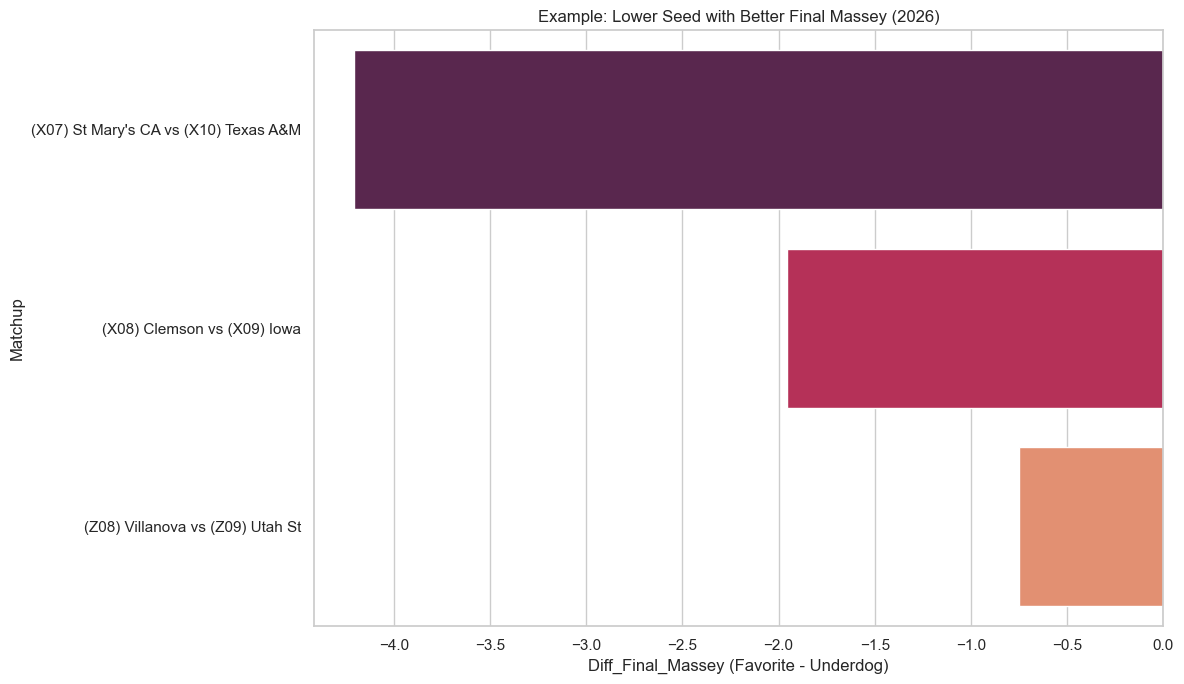

In [33]:
# Open-ended challenge ideas:
# 1) focus only on play-in paths
# 2) rank biggest negative Diff_Final_Massey games
# 3) compare regions side-by-side

example_df = (
    round1_with_modeling.dropna(subset=["Diff_Final_Massey"])
    .query("Diff_Final_Massey < 0")
    .sort_values("Diff_Final_Massey")
    .head(12)
    .copy()
)

if example_df.empty:
    print("No negative Diff_Final_Massey matchups found for this setup.")
else:
    plt.figure(figsize=(12, 7))
    sns.barplot(data=example_df, x="Diff_Final_Massey", y="MatchupLabel", palette="rocket")
    plt.title(f"Example: Lower Seed with Better Final Massey ({SEASON})")
    plt.xlabel("Diff_Final_Massey (Favorite - Underdog)")
    plt.ylabel("Matchup")
    plt.tight_layout()
    plt.show()